# Rain Prediction — End-to-End ML Pipeline

This notebook walks through the complete pipeline for predicting whether it will rain at a given hour, based on meteorological sensor data. It covers:

1. **Exploratory Data Analysis (EDA)** — understanding feature distributions and correlations  
2. **Data Preprocessing** — cleaning, feature engineering, and scaling  
3. **Model Training & Evaluation** — comparing RandomForest, XGBoost, and LightGBM  
4. **Results & Conclusions** — interpreting metrics and selecting the best model

---


## 1. Exploratory Data Analysis (EDA)

Before building any model, it's essential to understand the structure of the data. The dataset contains **hourly meteorological observations** (temperature, humidity, cloud cover, wind, pressure, etc.) and a rain measurement column used to derive a binary target: `rain_class` (1 = rain, 0 = no rain).

### 1.1 EDA Script Overview

The `feature_analysis.py` script performs three analyses:
- Computes a **correlation matrix** across all numeric features
- Ranks features by their **correlation with the rain target**
- Plots the **distributions of the top 4 features** split by rain class

> Target-leaking columns (`precipitation`, `rain`, `snowfall`) are excluded from EDA to prevent artificially inflated correlations.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def run_eda(filepath, output_dir):
    print(f"Loading data from {filepath}...")
    df = pd.read_csv(filepath)
    print(f"Dataset Shape: {df.shape}")

    # Create binary target: 1 if rain > 0
    df['rain_class'] = (df['rain '] > 0.0).astype(int)

    # Standardise column names
    df.columns = [col.strip() for col in df.columns]

    # Select numeric features only; drop direct rain-leaking columns
    df_numeric = df.select_dtypes(include=[np.number])
    cols_to_exclude = ['rain', 'precipitation', 'snowfall']
    df_features = df_numeric.drop(columns=[c for c in cols_to_exclude if c in df_numeric.columns])



### 1.2 Feature Correlation Matrix

The heatmap below shows **pairwise Pearson correlations** between all meteorological features (lower-triangle only to avoid redundancy). Key observations:

| Pair | Correlation | Interpretation |
|---|---|---|
| `wind_speed_10m` ↔ `wind_gusts_10m` | **0.95** | Near-perfect — wind gusts are simply peak wind speed |
| `wind_speed_100m` ↔ `wind_speed_10m` | **0.95** | Wind speeds at different heights are tightly coupled |
| `cloud_cover` ↔ `cloud_cover_highh` | **0.76** | High clouds dominate total cloud cover |
| `relative_humidity_2m` ↔ `temperature_2m` | **−0.73** | Classic inverse relationship: warm air holds more moisture |
| `pressure_msl` ↔ `cloud_cover_mid` | **−0.43** | Low pressure systems bring mid-level clouds |

> **Multicollinearity takeaway**: `wind_speed_10m` and `wind_gusts_10m` are almost perfectly correlated. One can be dropped without information loss — the pipeline removes `wind_speed_10m` during preprocessing.


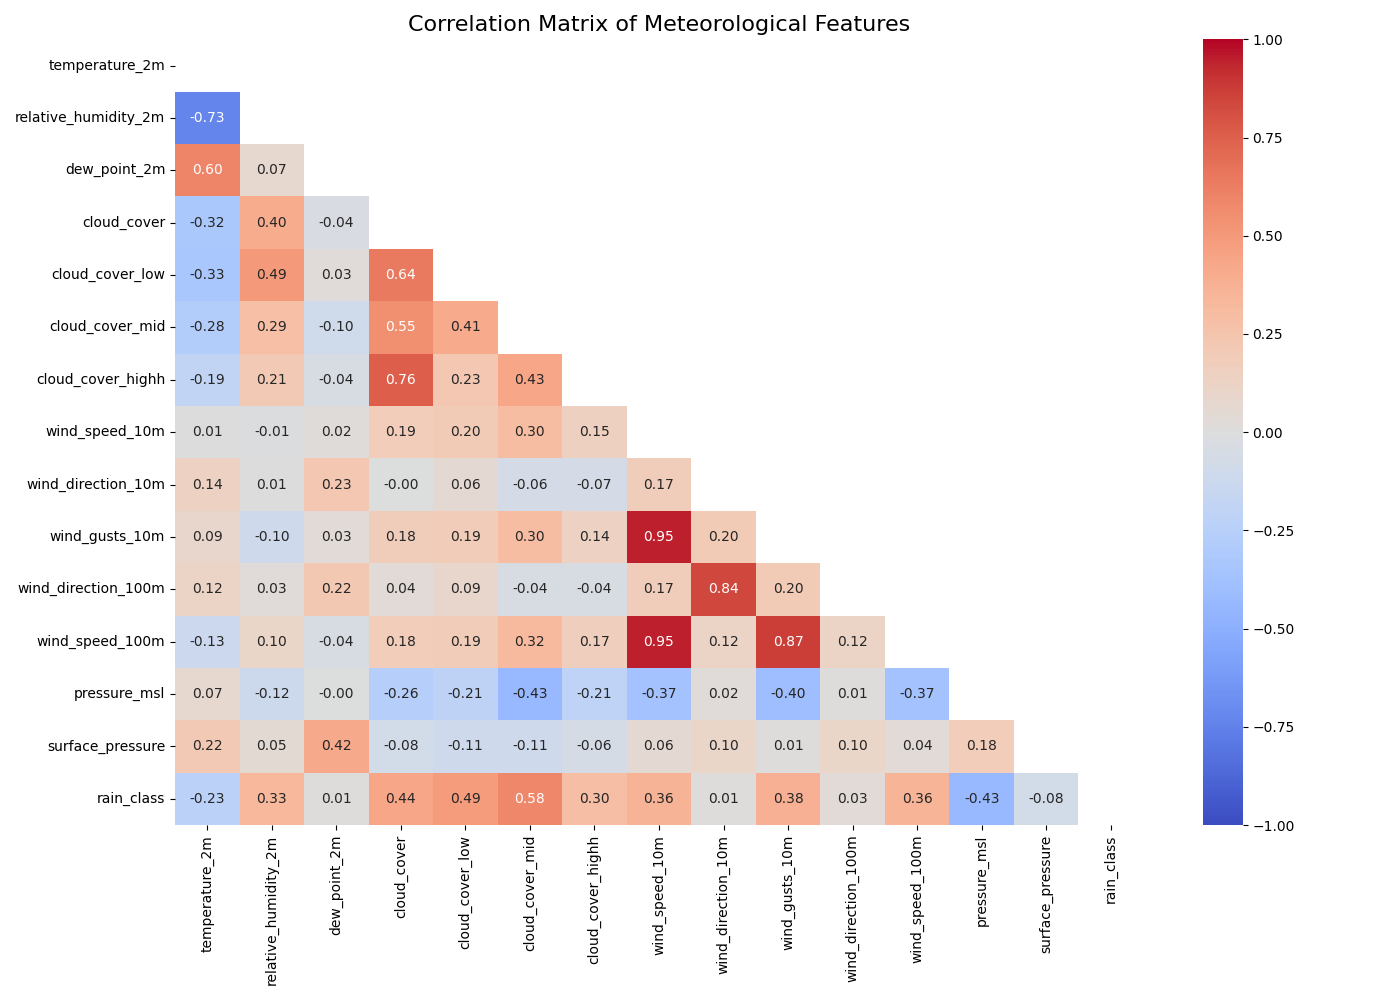

In [11]:
from pathlib import Path
from IPython.display import Image, display

def _eda_dir():
    local = Path.cwd() / "eda"
    if local.exists():
        return local
    nested = Path.cwd() / "Level_1_Rain_Classification" / "eda"
    if nested.exists():
        return nested
    return Path("eda")

heatmap_path = _eda_dir() / "correlation_heatmap.png"
if heatmap_path.exists():
    display(Image(filename=str(heatmap_path)))
else:
    print(f"Imagem nao encontrada: {heatmap_path}")

### 1.3 Feature Correlation with Rain (`rain_class`)

This bar chart ranks every feature by how strongly it correlates (positively or negatively) with whether it rains.

**Top positive predictors of rain:**
- `cloud_cover_mid` (**+0.58**) — mid-level clouds are the strongest single signal; these are the clouds that typically produce precipitation
- `cloud_cover_low` (**+0.49**) — low clouds (stratus/nimbostratus) are directly associated with rainfall
- `cloud_cover` (**+0.44**) — total cloud cover confirms the pattern
- `wind_gusts_10m` (**+0.38**) and `wind_speed_10m` (**+0.36**) — stronger winds accompany frontal systems

**Negative predictors of rain:**
- `pressure_msl` (**−0.43**) — high barometric pressure suppresses rainfall; low pressure brings storms
- `temperature_2m` (**−0.23**) — lower temperatures slightly associate with rain (cold fronts), though the signal is weak
- `surface_pressure` (**−0.08**) — weak negative effect

> Features like `dew_point_2m` and `wind_direction` show near-zero correlation, suggesting they add little predictive value on their own.


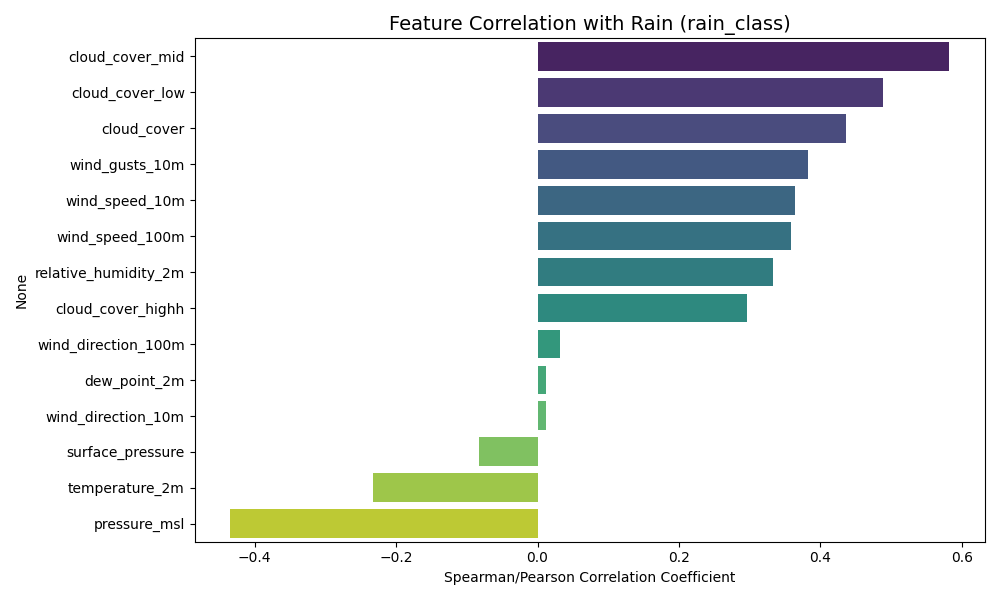

In [12]:
from pathlib import Path
from IPython.display import Image, display

def _eda_dir():
    local = Path.cwd() / "eda"
    if local.exists():
        return local
    nested = Path.cwd() / "Level_1_Rain_Classification" / "eda"
    if nested.exists():
        return nested
    return Path("eda")

target_corr_path = _eda_dir() / "target_correlation.png"
if target_corr_path.exists():
    display(Image(filename=str(target_corr_path)))
else:
    print(f"Imagem nao encontrada: {target_corr_path}")

### 1.4 Feature Distributions by Rain Class

The KDE plots compare the distribution of each top feature for `rain_class = 0` (no rain) and `rain_class = 1` (rain).

**Main patterns:**
- `cloud_cover_mid`, `cloud_cover_low`, and `cloud_cover` show strong separation: rainy hours (`rain_class = 1`) are concentrated near very high cloud coverage (close to 100), while non-rainy hours (`rain_class = 0`) are concentrated at much lower values.
- `pressure_msl` shows the opposite behavior: rainy hours are shifted toward lower pressure values, and non-rainy hours are shifted toward higher pressure values.
- The overlap regions indicate uncertain cases where both classes can occur, which explains some false positives/false negatives in classification.

**Interpretation:**
These distributions support the correlation results: cloud-related variables are strong positive predictors of rain, while sea-level pressure is a strong negative predictor.

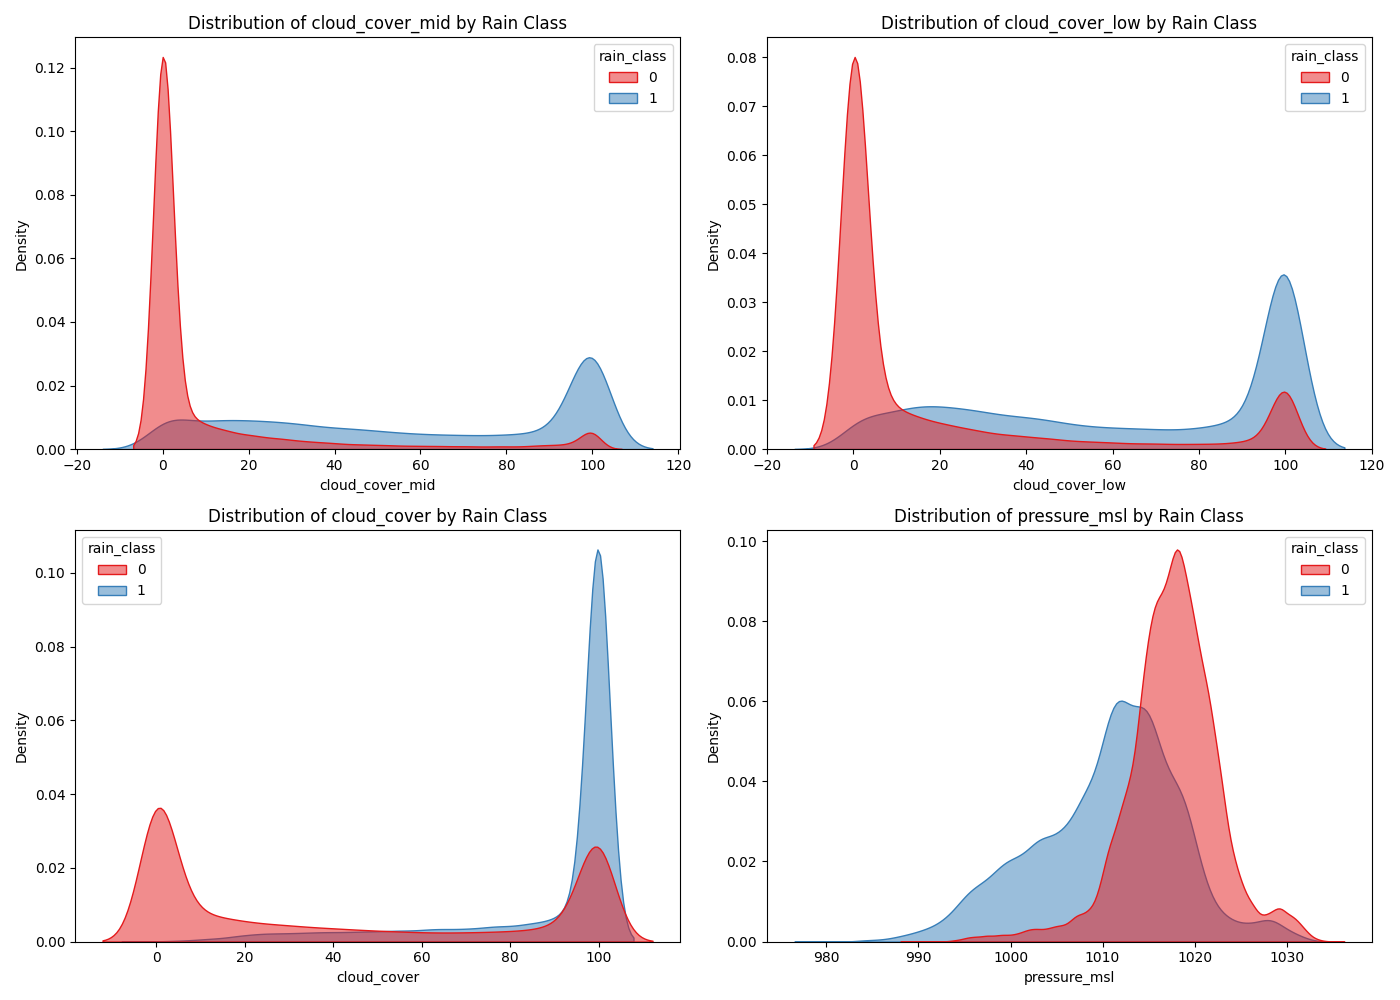

In [13]:
from pathlib import Path
from IPython.display import Image, display

def _eda_dir():
    local = Path.cwd() / "eda"
    if local.exists():
        return local
    nested = Path.cwd() / "Level_1_Rain_Classification" / "eda"
    if nested.exists():
        return nested
    return Path("eda")

dist_path = _eda_dir() / "top_features_distribution.png"
if dist_path.exists():
    display(Image(filename=str(dist_path)))
else:
    print(f"Imagem nao encontrada: {dist_path}")

---
## 2. Data Preprocessing (`load_and_preprocess_data`)

The preprocessing pipeline in `rain_prediction.py` prepares the raw CSV for model training through several steps.


In [5]:
# rain_prediction.py — Preprocessing pipeline
# (abridged for readability; see full source for complete implementation)

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

def load_and_preprocess_data(filepath, return_context=False):
    df = pd.read_csv(filepath)

    # ── Step 1: Clean column names ────────────────────────────────────────────
    df.columns = [col.strip() for col in df.columns]

    # ── Step 2: Drop rows with missing values ─────────────────────────────────
    df = df.dropna()

    # ── Step 3: Temporal feature engineering ─────────────────────────────────
    # Parse datetime and extract hour + month
    df['time'] = pd.to_datetime(df['time'])
    df['month'] = df['time'].dt.month
    df['hour']  = df['time'].dt.hour

    # Cyclical encoding: maps hour/month onto a circle so Jan≈Dec and 23:00≈00:00
    df['hour_sin']   = np.sin(2 * np.pi * df['hour']  / 24)
    df['hour_cos']   = np.cos(2 * np.pi * df['hour']  / 24)
    df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)

    # ── Step 4: Create binary target ─────────────────────────────────────────
    df['rain_class'] = (df['rain'] > 0.0).astype(int)   # 1 = rain, 0 = no rain

    # ── Step 5: Encode categorical location ──────────────────────────────────
    le = LabelEncoder()
    df['location_encoded'] = le.fit_transform(df['location'])

    # ── Step 6: Drop leaking / redundant columns ──────────────────────────────
    # 'rain', 'precipitation', 'snowfall' directly reveal the target
    # 'wind_speed_10m' dropped due to 0.95 correlation with wind_gusts_10m
    cols_to_drop = ['time', 'location', 'rain', 'wind_speed_10m',
                    'precipitation', 'snowfall']
    df_processed = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    # ── Step 7: Standard scaling ──────────────────────────────────────────────
    # Scale raw numerical features; leave encoded/cyclical features as-is
    feature_cols = [
        col for col in df_processed.columns
        if col not in ['rain_class', 'location_encoded',
                       'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
        and df_processed[col].dtype in [np.float64, np.int64]
    ]
    scaler = StandardScaler()
    df_processed[feature_cols] = scaler.fit_transform(df_processed[feature_cols])

    return df_processed


### Preprocessing Design Decisions

| Decision | Rationale |
|---|---|
| **Cyclical encoding** for hour/month | Linear encoding treats 23 as far from 0; cyclical encoding correctly places midnight next to 11 PM |
| **Drop `wind_speed_10m`** | 0.95 correlation with `wind_gusts_10m` makes it redundant — keeping both risks multicollinearity |
| **Drop `precipitation` / `snowfall`** | These columns directly measure rain — including them would be target leakage |
| **StandardScaler** applied | Tree-based models are scale-invariant, but scaling ensures compatibility if linear models are added later |
| **Stratified splits** | The dataset has a class imbalance (~80% no-rain, ~20% rain); stratification preserves this ratio across train/val/test |


---
## 3. Model Training & Evaluation

Three gradient-boosting / ensemble models were compared using an **80 / 10 / 10 stratified split** (126,489 train | 15,811 val | 15,812 test).

### Dataset Split
| Set | Samples |
|---|---|
| Train | 126,489 |
| Validation | 15,811 |
| Test | 15,812 |

The primary metric is **F1-score** on the positive (rain) class, balancing precision and recall.  
All models handle the class imbalance explicitly:
- **RandomForest / LightGBM**: `class_weight='balanced'`
- **XGBoost**: `scale_pos_weight` set to the no-rain/rain ratio (~4:1)


In [10]:
# rain_prediction.py — Model definitions and training loop
# (abridged — see full source for complete implementation)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report

def get_models_and_params(scale_pos_weight=4.0):
    return {
        "RandomForest": RandomForestClassifier(
            class_weight='balanced', random_state=42, n_jobs=-1,
            n_estimators=200, max_depth=10, min_samples_leaf=10
        ),
        "XGBoost": XGBClassifier(
            scale_pos_weight=scale_pos_weight, random_state=42,
            n_estimators=400, learning_rate=0.05, max_depth=5,
            subsample=0.8, colsample_bytree=0.8,
            reg_lambda=1, reg_alpha=0.1, early_stopping_rounds=30, n_jobs=-1
        ),
        "LightGBM": LGBMClassifier(
            class_weight='balanced', random_state=42, verbosity=-1,
            n_estimators=200, max_depth=8, learning_rate=0.2, num_leaves=63
        ),
    }

def train_and_evaluate(df):
    X, y = df.drop(columns=['rain_class']), df['rain_class']

    # 80 / 10 / 10 stratified split
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

    scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())
    models = get_models_and_params(scale_pos_weight)

    results = {}
    for name, model in models.items():
        if name == "XGBoost":
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        else:
            model.fit(X_train, y_train)

        results[name] = {split: evaluate(model, X, y)
                         for split, (X, y) in [("train",      (X_train, y_train)),
                                                ("validation", (X_val,   y_val)),
                                                ("test",       (X_test,  y_test))]}
    return results


---
## 4. Results & Model Comparison

### 4.1 Summary Table

| Rank | Model | Val F1 | Test F1 | Val Precision | Val Recall |
|---|---|---|---|---|---|
| 1 | **LightGBM** | **0.8014** | **0.7985** | 0.7229 | 0.8990 |
| 2 | XGBoost | 0.7790 | 0.7754 | 0.6713 | 0.9280 |
| 3 | RandomForest | 0.7486 | 0.7435 | 0.6265 | 0.9299 |

All three models were ranked by **Validation F1** to select hyperparameters without touching the test set.


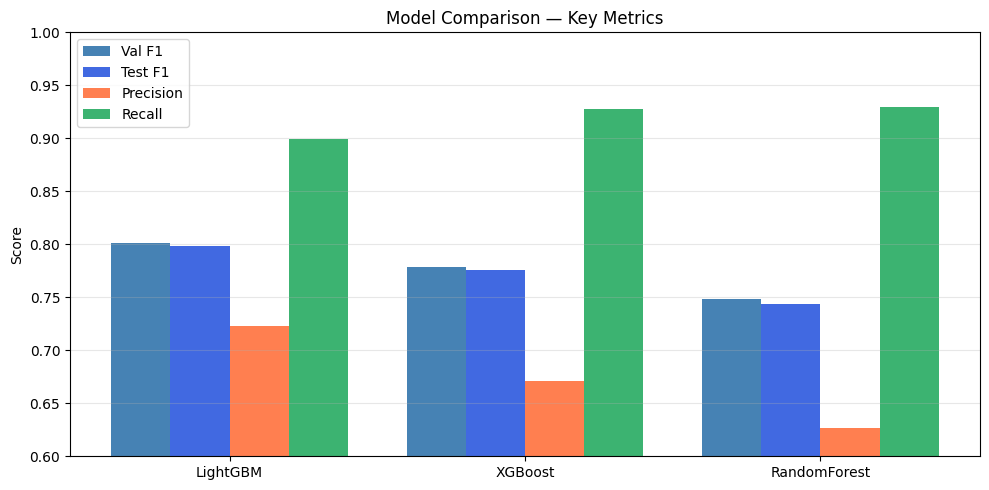

In [7]:
# Model metrics visualisation
import matplotlib.pyplot as plt
import numpy as np

models    = ['LightGBM', 'XGBoost', 'RandomForest']
val_f1    = [0.8014, 0.7790, 0.7486]
test_f1   = [0.7985, 0.7754, 0.7435]
precision = [0.7229, 0.6713, 0.6265]
recall    = [0.8990, 0.9280, 0.9299]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 1.5*width, val_f1,    width, label='Val F1',    color='steelblue')
ax.bar(x - 0.5*width, test_f1,   width, label='Test F1',   color='royalblue')
ax.bar(x + 0.5*width, precision, width, label='Precision', color='coral')
ax.bar(x + 1.5*width, recall,    width, label='Recall',    color='mediumseagreen')

ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0.6, 1.0); ax.set_ylabel('Score'); ax.set_title('Model Comparison — Key Metrics')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


### 4.2 Per-Model Deep Dive

#### LightGBM (Best Model)
**Hyperparameters**: `n_estimators=200, max_depth=8, learning_rate=0.2, num_leaves=63`

| Split | F1 | Precision | Recall |
|---|---|---|---|
| Train | 0.8918 | 0.8097 | 0.9923 |
| Validation | 0.8014 | 0.7229 | 0.8990 |
| Test | 0.7985 | 0.7198 | 0.8965 |

- **Val→Test F1 drop: only 0.003** — extremely stable, no overfitting to validation set  
- **Train→Val F1 gap: 0.09** — within acceptable range; not flagged as overfitting  
- High recall (0.90) means the model correctly catches **~90% of all rainy hours** — important for a weather application where missing rain is costly  
- Lower precision (0.72) means ~28% of predicted-rain hours are false alarms

#### XGBoost
**Hyperparameters**: `n_estimators=400, lr=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, λ=1, α=0.1`

- Slightly lower F1 than LightGBM but **higher recall (0.928)** — catches slightly more rain events  
- Lower precision (0.67) means more false positives  
- `early_stopping_rounds=30` prevents training past the optimal iteration

#### RandomForest
**Hyperparameters**: `n_estimators=200, max_depth=10, min_samples_leaf=10`

- Weakest of the three on F1, but highest recall (0.930)  
- `min_samples_leaf=10` acts as regularisation, preventing overly specific leaf rules  
- Simpler to interpret than gradient boosting methods


### 4.3 Confusion Matrix Analysis (LightGBM — Test Set)

```
Predicted:     No Rain    Rain
Actual No Rain  11,575    1,096   ← 1,096 false alarms
Actual Rain        325    2,816   ← 325 missed rain events
```

- **True Negatives (11,575)**: correctly predicted dry — 91.4% of actual dry hours  
- **True Positives (2,816)**: correctly predicted rain — 89.6% of actual rainy hours  
- **False Negatives (325)**: missed rain — 10.4% of actual rainy hours → acceptable for most use cases  
- **False Positives (1,096)**: predicted rain but was dry — the main source of imprecision


### 4.4 Overfitting Analysis

LightGBM shows a **Train F1 of 0.892 vs. Validation F1 of 0.801** — a gap of ~0.09. The pipeline uses a threshold of 0.10 for the overfitting warning:

```
Train F1: 0.8918 | Validation F1: 0.8014
→ No significant overfitting detected.
```

The gap is partially explained by the training set being 8× larger, giving the model more patterns to memorise during training. The Validation↔Test consistency (0.8014 vs 0.7985) confirms the model generalises well.


---
## 5. Inference — Predicting Rain for a Specific Day

The trained model supports **location-aware, date-specific predictions** via `predict_rain_for_day()`. Models are cached to disk after the first training run to avoid retraining on subsequent calls.


In [14]:
# rain_prediction.py — Inference API (abridged)
# The model is trained once, then cached to .cache/level1/ for reuse.

def predict_rain_for_day(filepath, selected_date, location, model_family="all", profile="balanced"):
    """
    Returns hourly rain predictions for a given date and location.

    Parameters
    ----------
    filepath      : str  — path to the meteorology CSV
    selected_date : str  — e.g. '2023-07-14'
    location      : str  — e.g. 'Porto'
    model_family  : str  — 'all' (best of 3), 'rf', 'xgb', or 'lgbm'
    profile       : str  — 'balanced', 'recall' (fewer misses), 'precision' (fewer alarms)

    Returns
    -------
    dict with keys:
        willRain        — bool: is any rain predicted for the day?
        confidence      — float: mean predicted rain probability across hours
        rainyHours      — int: number of hours predicted as rainy
        hourly          — list of per-hour predictions with time, confidence, observed values
        globalTestF1    — float: model performance on held-out test set
    """
    processed_df, context_df = load_and_preprocess_data(filepath, return_context=True)

    # Load (or train once) global model — cached to disk
    cached = _get_or_build_level1_model(filepath, processed_df, model_family, profile)
    model  = cached['model']

    # Filter to requested date + location
    mask = (context_df['time'].dt.normalize() == pd.Timestamp(selected_date)) & \
           (context_df['location'] == location)

    X_pred  = processed_df.loc[mask].drop(columns=['rain_class'])
    probs   = model.predict_proba(X_pred)[:, 1]    # rain probability per hour
    preds   = model.predict(X_pred)                 # binary prediction per hour

    return {
        'willRain':     bool(preds.any()),
        'confidence':   float(probs.mean()),
        'rainyHours':   int(preds.sum()),
        'modelName':    cached['modelName'],
        'globalTestF1': cached['testMetrics']['f1'],
        # ... hourly breakdown omitted for brevity
    }

# Example usage:
# result = predict_rain_for_day('data/meteorology_dataset.csv', '2023-07-14', 'Porto')
# print(result['willRain'], result['rainyHours'], 'rainy hours predicted')


---
## 6. Conclusions

- **LightGBM** delivered the best overall balance, with **Validation F1 = 0.8014** and **Test F1 = 0.7985**.
- The very small validation-to-test gap (~0.003) indicates **strong generalization** and stable model behavior.
- **Cloud-related features** (`cloud_cover_mid`, `cloud_cover_low`, `cloud_cover`) were the most informative predictors of rain events.
- **Pressure (`pressure_msl`)** consistently acted as a negative rain signal, aligning with meteorological expectations.
- **Cyclical time encoding** (`hour_sin/cos`, `month_sin/cos`) captured temporal periodicity without introducing artificial discontinuities.
- **Model caching** in the inference pipeline reduced latency by avoiding repeated retraining.
